# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is a linear if the dependent variable is expressed as a weighted sum of the coefficients and features, without multiplying or transforming the coefficients.
2. It represents the difference in the expected value of the dependent variable relative to a reference group. To avoid the dummy variable trap, one catergory (or the intercept) is removed and the omitted category becomes the baseline.
3. It is generally not appropriate because it assumes a continuous outcome and constant variance which are violated in classification. Models like logistic regression are preferred.
4. Very high performance on training data but poor performance on test data, large fluctuation in model predictions, low bias but high variance.
5. First stage: one correlated variable is regressed on others to isolate independent variation. Second stage: outcome is regressed on predicted component.
6. Nonlinear relationships can be incorporated by transforming variables but keeping linear model. Examples include log transformations, piecewise functions, etc.
7. The slope coefficient is the change in dependent variable for a one unit increase in the independent variable.
8. Train split divides the data once into training and testing sets. K-fold cross validation divides the data into k subsets and rotates the subset used as the test set.
9. The value of k is chosen to provide a good balance between efficiency and reliable estimates (trade-off between bias and variance).

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [12]:
import pandas as pd

df = pd.read_csv("Q1_clean.csv")

df = df.rename(columns={
    "Price": "price",
    "Review Scores Rating": "review_score",
    "Neighbourhood ": "neighbourhood",
    "Property Type": "property_type",
    "Room Type": "room_type"
})

print(df.columns)
print(df.head())

Index(['price', 'review_score', 'neighbourhood', 'property_type', 'room_type'], dtype='object')
   price  review_score neighbourhood property_type        room_type
0    549          96.0     Manhattan     Apartment     Private room
1    149         100.0      Brooklyn     Apartment  Entire home/apt
2    250         100.0     Manhattan     Apartment  Entire home/apt
3     90          94.0      Brooklyn     Apartment     Private room
4    270          90.0     Manhattan     Apartment  Entire home/apt


In [13]:
#1
group_means = df.groupby("neighbourhood")[["price", "review_score"]].mean()

group_means = group_means.sort_values("price", ascending=False)

print(group_means)

most_expensive = group_means.index[0]
avg_price = group_means.iloc[0]["price"]

print("\nMost expensive borough:", most_expensive)
print("Average price:", avg_price)

                    price  review_score
neighbourhood                          
Manhattan      183.664286     91.801496
Staten Island  146.166667     90.843750
Brooklyn       127.747378     92.363497
Queens          96.857233     91.549057
Bronx           75.276498     91.654378

Most expensive borough: Manhattan
Average price: 183.6642863215166


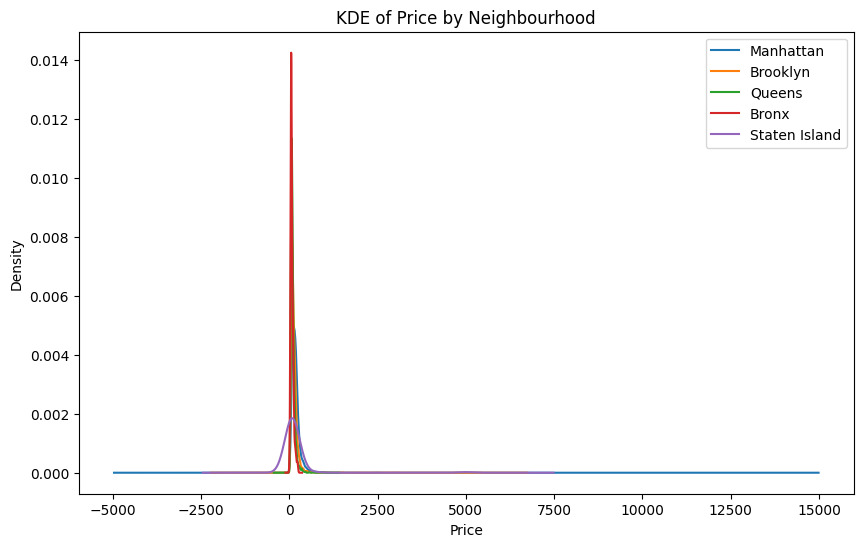

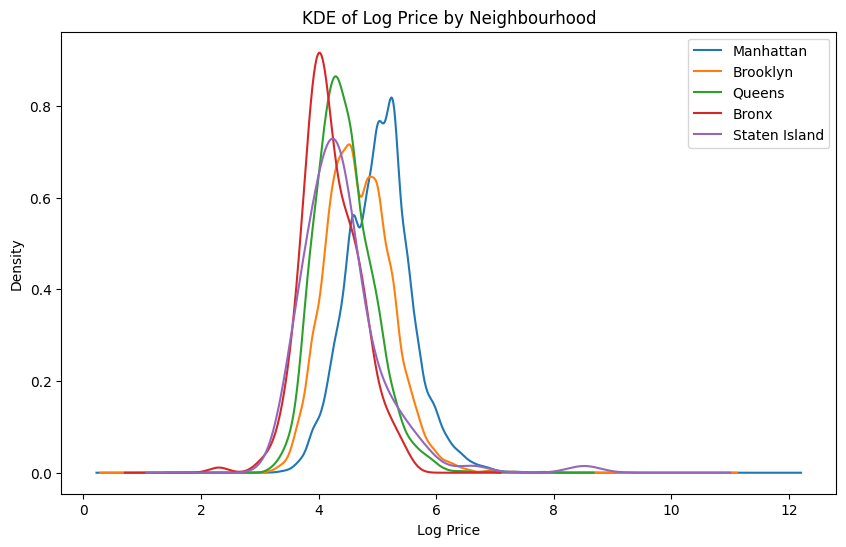

In [14]:
import numpy as np
import matplotlib.pyplot as plt

df = df.dropna(subset=["price", "neighbourhood"])
df = df[df["price"] > 0].copy()
df["log_price"] = np.log(df["price"])

plt.figure(figsize=(10, 6))
for n in df["neighbourhood"].unique():
    df[df["neighbourhood"] == n]["price"].plot(kind="kde", label=n)

plt.title("KDE of Price by Neighbourhood")
plt.xlabel("Price")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for n in df["neighbourhood"].unique():
    df[df["neighbourhood"] == n]["log_price"].plot(kind="kde", label=n)

plt.title("KDE of Log Price by Neighbourhood")
plt.xlabel("Log Price")
plt.legend()
plt.show()

In [15]:
#Q2
import statsmodels.api as sm

model = sm.OLS.from_formula("price ~ C(neighbourhood)", data=df).fit()

print(model.summary())
print("\nCoefficients:\n")
print(model.params)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        00:57:22   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [16]:
print("\nGroup means:\n")
print(group_means)

coefs = model.params
intercept = coefs["Intercept"]

print("\nIntercept (reference group mean):", intercept)

print("\nReconstructed means from regression:")
for name in coefs.index:
    if name == "Intercept":
        print(f"Reference group mean: {intercept}")
    else:
        borough = name.split("[T.")[1].replace("]", "")
        print(f"{borough}: {intercept + coefs[name]}")


Group means:

                    price  review_score
neighbourhood                          
Manhattan      183.664286     91.801496
Staten Island  146.166667     90.843750
Brooklyn       127.747378     92.363497
Queens          96.857233     91.549057
Bronx           75.276498     91.654378

Intercept (reference group mean): 75.27649769585317

Reconstructed means from regression:
Reference group mean: 75.27649769585317
Brooklyn: 127.74737834334881
Manhattan: 183.66428632151622
Queens: 96.85723270440262
Staten Island: 146.16666666666742


When both neighbourhood and review score are included in the regression, the slope coefficient on review score decreases relative to the model without neighbourhood controls, indicating that part of the original relationship between ratings and price was driven by higher-priced boroughs like Manhattan also having slightly different average ratings. After controlling for neighbourhood, the coefficient reflects the within-borough effect of review scores on price. Similarly, the neighbourhood coefficients no longer match the raw group means from Part 1 (e.g., Manhattan ≈ 183.7, Brooklyn ≈ 127.7), but instead represent differences in price across boroughs holding review score constant, meaning they are adjusted rather than unconditional averages.


In [17]:
#Q3
model_rs = sm.OLS.from_formula("price ~ review_score", data=df).fit()

print(model_rs.summary())
print("\nCoefficients:\n")
print(model_rs.params)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        00:57:22   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       60.8784     10.423      5.841   

The estimated slope coefficient on review score is approximately 1.02, indicating that for each one-point increase in the review score, the nightly price is expected to increase by about $1.02 on average. This suggests a positive relationship between ratings and price, meaning higher-rated listings tend to be slightly more expensive. The intercept of about 60.88 represents the predicted price when the review score is zero, though this value is not practically meaningful since review scores do not realistically take values near zero.


In [18]:
#Q4
model_full = sm.OLS.from_formula("price ~ C(neighbourhood) + review_score", data=df).fit()

print(model_full.summary())
print("\nCoefficients:\n")
print(model_full.params)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        00:57:22   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

When neighbourhood is added to the regression, the slope coefficient on review score increases slightly from about 1.02 to 1.08, indicating that after controlling for location, higher review scores are associated with a slightly larger increase in price. This suggests that the initial estimate understated the relationship due to differences across boroughs. The neighbourhood coefficients no longer reflect raw average prices (e.g., Manhattan ≈ 183.7, Brooklyn ≈ 127.7), but instead represent price differences relative to the omitted borough (Bronx) while holding review score constant. For example, listings in Manhattan are estimated to be about $108 more expensive than those in the Bronx, conditional on having the same review score, meaning these are adjusted neighbourhood effects rather than simple group means.


In [19]:
#Q5
model_interact = sm.OLS.from_formula(
    "price ~ C(neighbourhood) * review_score",
    data=df
).fit()

print(model_interact.summary())
print("\nCoefficients:\n")
print(model_interact.params)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:57:23   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

The slopes are generally similar across most neighbourhoods, but there is a clear exception. For Brooklyn and Manhattan, the interaction terms are small and positive, implying slopes close to the baseline and therefore similar relationships between review score and price. Queens also shows a very small difference, suggesting little variation in slope. However, Staten Island is a major outlier, with a very large negative interaction term, indicating a drastically different (and much lower) slope compared to other boroughs. Overall, the slopes are similar across most neighbourhoods except for Staten Island, which behaves very differently.


In [20]:
#Q6
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

In [21]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [22]:
X4 = df[["review_score"]]
y = df["price"]

model4 = LinearRegression()

cv4 = cross_val_score(model4, X4, y, cv=kf, scoring=rmse_scorer)
print("Model 4 RMSE:", -cv4.mean())

Model 4 RMSE: 144.1736262473453


In [23]:
X5 = df[["neighbourhood", "review_score"]]

preprocess5 = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), ["neighbourhood"]),
    ("num", "passthrough", ["review_score"])
])

pipe5 = Pipeline([
    ("prep", preprocess5),
    ("model", LinearRegression())
])

cv5 = cross_val_score(pipe5, X5, y, cv=kf, scoring=rmse_scorer)
print("Model 5 RMSE:", -cv5.mean())

Model 5 RMSE: 140.51652264524586


In [24]:
X6 = pd.get_dummies(df["neighbourhood"], drop_first=True)

X6["review_score"] = df["review_score"]

for col in X6.columns:
    if col != "review_score":
        X6[f"{col}_x_review"] = X6[col] * df["review_score"]

model6 = LinearRegression()

cv6 = cross_val_score(model6, X6, y, cv=kf, scoring=rmse_scorer)
print("Model 6 RMSE:", -cv6.mean())

Model 6 RMSE: 141.56707344661342


In [25]:
print("\nSummary:")
print("Model 4 (review only):", -cv4.mean())
print("Model 5 (add neighbourhood):", -cv5.mean())
print("Model 6 (interaction):", -cv6.mean())


Summary:
Model 4 (review only): 144.1736262473453
Model 5 (add neighbourhood): 140.51652264524586
Model 6 (interaction): 141.56707344661342


Model 5 performs best, with the lowest RMSE of approximately 140.52, indicating that including neighbourhood improves predictive accuracy compared to using review score alone. Model 4 has the highest RMSE (about 144.17), showing that review score by itself is a relatively weak predictor of price. Model 6, which adds interaction terms, performs slightly worse than Model 5 (RMSE ≈ 141.57), suggesting that allowing slopes to vary by neighbourhood does not meaningfully improve predictive performance and may introduce unnecessary complexity.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [26]:
#Q1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cars = pd.read_csv("cars_hw.csv")

print(cars["Price"].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


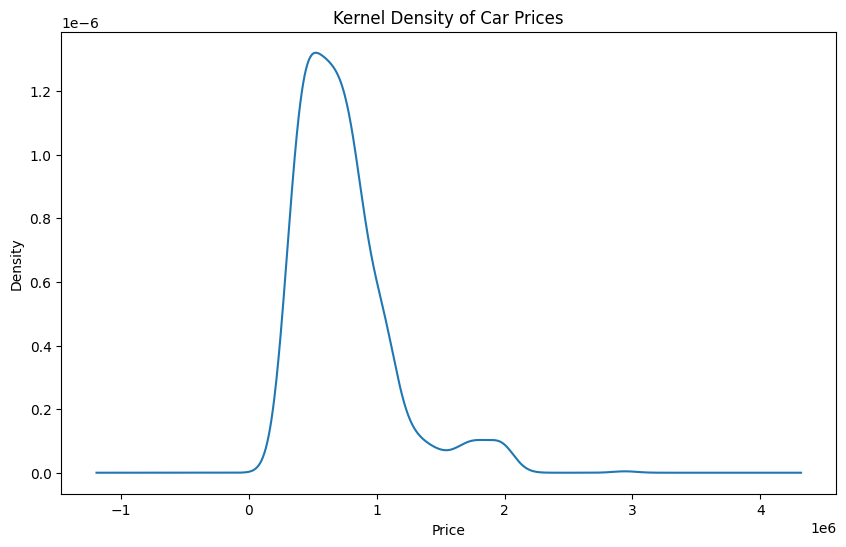

In [27]:
plt.figure(figsize=(10, 6))
cars["Price"].plot(kind="kde")

plt.title("Kernel Density of Car Prices")
plt.xlabel("Price")
plt.show()

In [28]:
group_summary = cars.groupby("Body_Type")["Price"].describe()
print(group_summary)

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


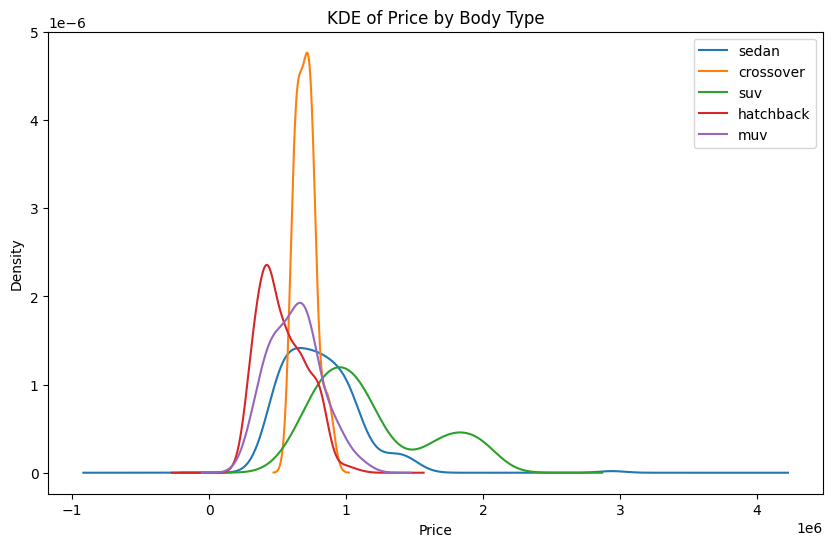

In [29]:
plt.figure(figsize=(10, 6))

for b in cars["Body_Type"].dropna().unique():
    cars[cars["Body_Type"] == b]["Price"].plot(kind="kde", label=b)

plt.title("KDE of Price by Body Type")
plt.xlabel("Price")
plt.legend()
plt.show()

Crossover cars are the most expensive. SUV cars have the most variance.

In [30]:
#Q2
import statsmodels.api as sm

model_seat = sm.OLS.from_formula("Price ~ Seating_Capacity", data=cars).fit()

print(model_seat.summary())
print("\nCoefficients:\n")
print(model_seat.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        00:57:24   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

The estimated slope coefficient on Seating_Capacity is approximately 59,268, meaning that each additional seat is associated with an increase in car price of about ₹59,268 on average. This indicates a positive relationship between seating capacity and price, suggesting that larger vehicles tend to be more expensive.


In [31]:
model_seat_cat = sm.OLS.from_formula("Price ~ C(Seating_Capacity)", data=cars).fit()

print(model_seat_cat.summary())
print("\nCoefficients:\n")
print(model_seat_cat.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000267
Time:                        00:57:24   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

When Seating_Capacity is treated as categorical, the coefficients show that price differences across seat counts are not linear. While 6-seat vehicles have a much higher price, 7-seat vehicles are lower than that, and 8-seat vehicles are even lower, which breaks the pattern of steadily increasing prices. Compared to the linear model, which assumes a constant increase of about 59,268 per additional seat, the categorical model reveals that the relationship is uneven and non-monotonic. Therefore, the differences in price are not roughly linear in the number of seats.


In [32]:
#Q3
cars["Age"] = 2026 - cars["Make_Year"]

print(cars[["Make_Year", "Age"]].head())

   Make_Year  Age
0       2017    9
1       2016   10
2       2019    7
3       2017    9
4       2017    9


In [33]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

y = cars["Price"]

results = {}

for d in range(1, 7):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    X = cars[["Age"]]

    scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
    results[d] = -scores.mean()

for d, score in results.items():
    print(f"Degree {d}: RMSE = {score}")

Degree 1: RMSE = 310765.36071398546
Degree 2: RMSE = 310779.2959641378
Degree 3: RMSE = 309697.34463849233
Degree 4: RMSE = 308871.56777749246
Degree 5: RMSE = 307368.98194909736
Degree 6: RMSE = 307522.52362407907


In [34]:
best_degree = min(results, key=results.get)

print("\nOptimal degree:", best_degree)
print("Lowest RMSE:", results[best_degree])


Optimal degree: 5
Lowest RMSE: 307368.98194909736


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


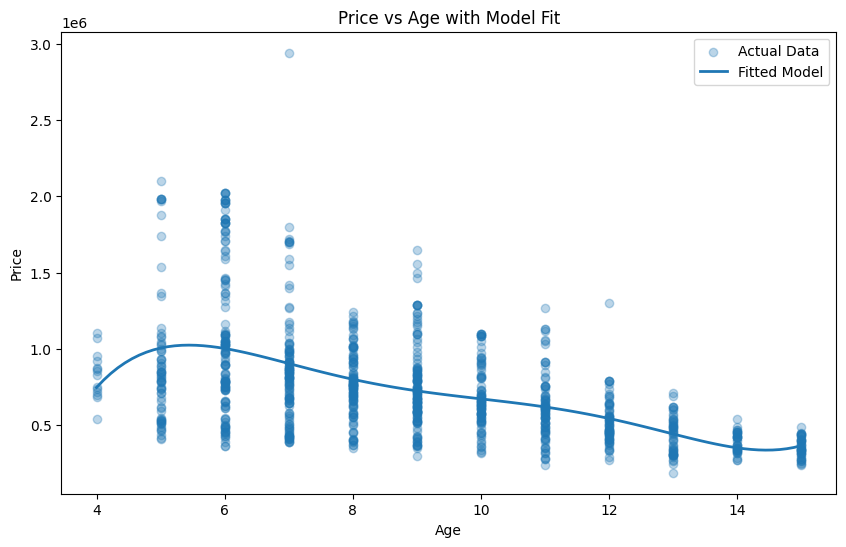

In [35]:
#Q4
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly.fit_transform(cars[["Age"]])

model = LinearRegression()
model.fit(X_poly, cars["Price"])

age_range = np.linspace(cars["Age"].min(), cars["Age"].max(), 100).reshape(-1, 1)
age_range_poly = poly.transform(age_range)

predicted_price = model.predict(age_range_poly)

plt.figure(figsize=(10, 6))

plt.scatter(cars["Age"], cars["Price"], alpha=0.3, label="Actual Data")

plt.plot(age_range, predicted_price, linewidth=2, label="Fitted Model")

plt.title("Price vs Age with Model Fit")
plt.xlabel("Age")
plt.ylabel("Price")
plt.legend()
plt.show()

The model captures the general relationship between price and age, showing that prices tend to decrease as vehicles get older, with some curvature in the relationship. However, there is still substantial scatter in the data, indicating that age alone does not fully explain variation in price. While the fitted curve follows the overall trend, it does not perfectly capture all patterns, suggesting that additional variables would be needed for a more accurate model.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [36]:
#Q1
import pandas as pd

heart = pd.read_csv("heart_hw.csv")

print(heart["transplant"].value_counts())

control_mean = heart[heart["transplant"] == "control"]["y"].mean()

treatment_mean = heart[heart["transplant"] == "treatment"]["y"].mean()

ate = treatment_mean - control_mean

print("Control survival rate:", control_mean)
print("Treatment survival rate:", treatment_mean)
print("ATE (treatment - control):", ate)

transplant
treatment    69
control      34
Name: count, dtype: int64
Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE (treatment - control): 0.23017902813299232


The average treatment effect (ATE) on three-year survival is approximately 0.230, meaning that receiving a heart transplant is associated with about a 23 percentage point increase in the probability of surviving three years compared to not receiving a transplant.


In [37]:
#Q2
import statsmodels.api as sm

heart["treatment"] = (heart["transplant"] == "treatment").astype(int)

model_ate = sm.OLS.from_formula("y ~ treatment", data=heart).fit()

print(model_ate.summary())
print("\nCoefficients:\n")
print(model_ate.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        00:57:25   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1176      0.075      1.574      0.1

The intercept from the regression equals the average survival rate in the control group (about 0.118), while the coefficient on the treatment variable equals the difference in survival rates between the treatment and control groups (about 0.230). These match exactly with the values computed in part 1, confirming that the regression framework reproduces the sample means and the average treatment effect.


In [38]:
#Q3

model_age = sm.OLS.from_formula("y ~ treatment + age", data=heart).fit()

print(model_age.summary())
print("\nCoefficients:\n")
print(model_age.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        00:57:25   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7020      0.196      3.583      0.0

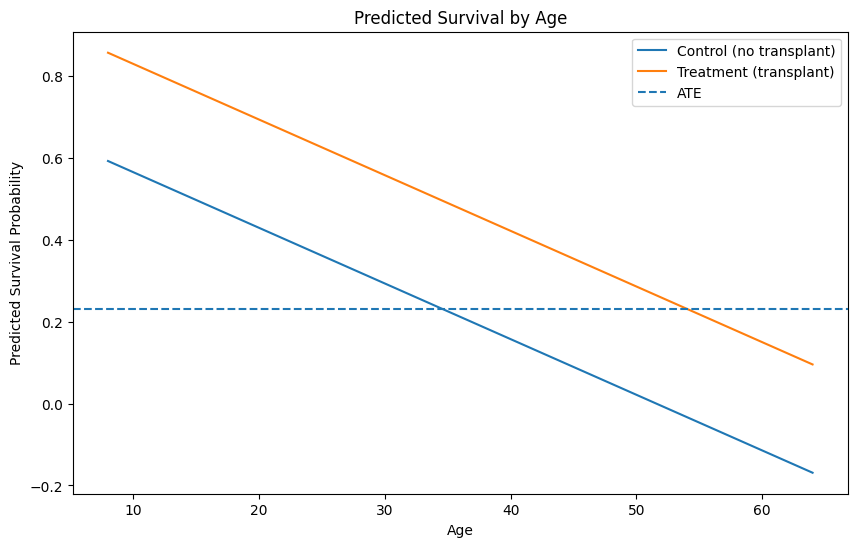

In [39]:
import numpy as np
import matplotlib.pyplot as plt

age_range = np.linspace(heart["age"].min(), heart["age"].max(), 100)

pred_control = model_age.params["Intercept"] + model_age.params["age"] * age_range

pred_treat = (
    model_age.params["Intercept"]
    + model_age.params["treatment"]
    + model_age.params["age"] * age_range
)

ate = 0.23017902813299232

plt.figure(figsize=(10, 6))

plt.plot(age_range, pred_control, label="Control (no transplant)")
plt.plot(age_range, pred_treat, label="Treatment (transplant)")

plt.axhline(y=ate, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

When age is included in the regression, the coefficient on transplant increases slightly from about 0.230 to 0.265, indicating that controlling for age strengthens the estimated treatment effect. The intercept represents the predicted probability of survival for a control individual with age equal to zero, while the coefficient on age (−0.0136) indicates that survival probability decreases by about 1.36 percentage points for each additional year of age, holding treatment constant.

From the plot, the ATE of 0.230 is constant across ages and underestimates the impact of a transplant roughly under 55, and over estimates over 55.


In [40]:
#Q4
model_interact = sm.OLS.from_formula("y ~ treatment * age", data=heart).fit()

print(model_interact.summary())
print("\nCoefficients:\n")
print(model_interact.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        00:57:25   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.3549      0.280      1.269

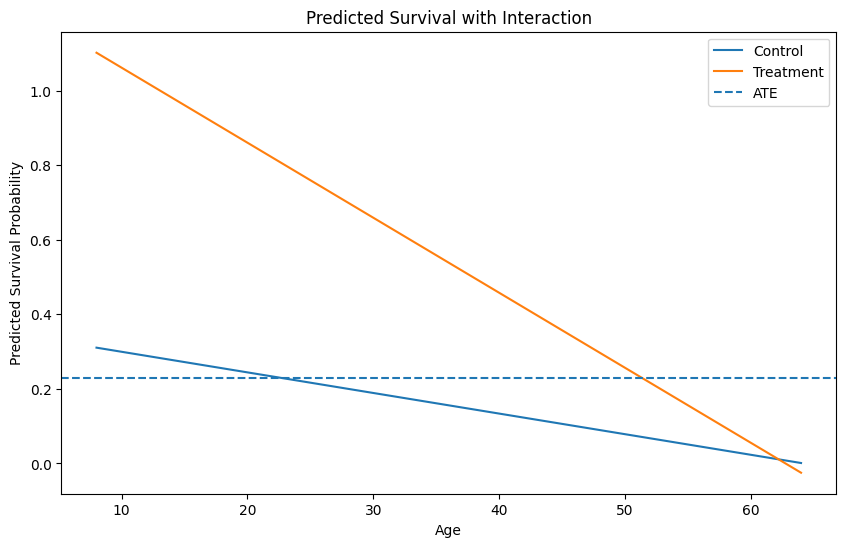

In [41]:
import numpy as np
import matplotlib.pyplot as plt

age_range = np.linspace(heart["age"].min(), heart["age"].max(), 100)

intercept = model_interact.params["Intercept"]
beta_treat = model_interact.params["treatment"]
beta_age = model_interact.params["age"]
beta_inter = model_interact.params["treatment:age"]

pred_control = intercept + beta_age * age_range

pred_treat = intercept + beta_treat + (beta_age + beta_inter) * age_range

ate = 0.23017902813299232

plt.figure(figsize=(10, 6))

plt.plot(age_range, pred_control, label="Control")
plt.plot(age_range, pred_treat, label="Treatment")

plt.axhline(y=ate, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival with Interaction")
plt.legend()
plt.show()

Allowing age and transplant to interact changes the model by letting the effect of the transplant vary with age rather than remain constant. Instead of parallel lines, the predicted survival curves for treatment and control now have different slopes, meaning the treatment effect depends on age. This reveals a clear pattern: the benefit of a transplant changes across age groups, either increasing or decreasing with age depending on the sign of the interaction term. As a result, the constant ATE from earlier no longer accurately summarizes the treatment effect, since the impact of a transplant is not uniform across individuals but varies systematically with age.


In [42]:
#Q5
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

y = heart["y"]

In [43]:
X1 = heart[["treatment"]]

model1 = LinearRegression()
cv1 = cross_val_score(model1, X1, y, cv=kf, scoring=rmse_scorer)

print("Model 1 RMSE:", -cv1.mean())

Model 1 RMSE: 0.43651009364500126


In [44]:
X2 = heart[["treatment", "age"]]

model2 = LinearRegression()
cv2 = cross_val_score(model2, X2, y, cv=kf, scoring=rmse_scorer)

print("Model 2 RMSE:", -cv2.mean())

Model 2 RMSE: 0.416697053853562


In [45]:
heart["treat_age"] = heart["treatment"] * heart["age"]

X3 = heart[["treatment", "age", "treat_age"]]

model3 = LinearRegression()
cv3 = cross_val_score(model3, X3, y, cv=kf, scoring=rmse_scorer)

print("Model 3 RMSE:", -cv3.mean())

Model 3 RMSE: 0.41295572153919125


In [46]:
print("\nSummary:")
print("Model 1 (treatment only):", -cv1.mean())
print("Model 2 (add age):", -cv2.mean())
print("Model 3 (interaction):", -cv3.mean())


Summary:
Model 1 (treatment only): 0.43651009364500126
Model 2 (add age): 0.416697053853562
Model 3 (interaction): 0.41295572153919125


Model 3 performs best, with the lowest RMSE of approximately 0.413, indicating that allowing for an interaction between treatment and age improves predictive accuracy. Model 2 also improves upon Model 1, showing that age is an important predictor of survival. The improvement from Model 2 to Model 3 suggests that the effect of treatment varies with age, and capturing this interaction provides additional predictive power.


Q5. A major concern is that the model is built on a very limited set of variables, so it may confuse correlation with true medical need. Age and treatment status alone leave out many clinically important factors such as disease severity, overall health, and social support. If a model like this were used to prioritize access, it could make decisions based on an incomplete picture and unfairly advantage or disadvantage certain patients.

There is also a serious fairness concern, especially because age enters the model so strongly. Even if age is predictive, relying heavily on it could systematically deprioritize older patients in a way that feels troubling or inconsistent with medical standards.

From a deployment perspective, this model should not be used as an automatic decision rule. At most, it could serve as one input alongside physician judgment, ethical review, and richer clinical data.
